In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

In [ ]:
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "sans-serif"

In [14]:
train_users = pd.read_csv("train_users.csv")
train_transactions = pd.read_csv("train_transactions.csv")

In [ ]:
train_users

,id_user,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud
0,15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0
1,9458117,2025-05-04 19:30:02.902877+00:00,evamark@yahoo.com,male,Romania,cpa,0
2,21312302,2025-09-07 18:24:51+00:00,stmark86@gmail.com,male,Austria,ppc,0
3,61828,2025-01-01 17:33:08.026088+00:00,robertwalker@gmail.com,male,Portugal,organic,1
4,13164211,2025-06-21 18:27:03.420098+00:00,sarah.miller@gmail.com,female,Belgium,organic,0
...,...,...,...,...,...,...,...
395376,15208750,2025-07-15 00:09:30.100536+00:00,alexpaterson@gmail.com,male,United States,cpa,0
395377,34511422,2025-12-22 16:25:42+00:00,kmiller216@gmail.com,male,United States,ppc,0
395378,28313259,2025-11-04 17:41:08+00:00,vams25@gmail.com,male,United States,ppc,0
395379,31685096,2025-12-01 15:28:38+00:00,lrwinpdx@gmail.com,female,United States,ppc,0


In [ ]:
train_transactions

,id_user,timestamp_tr,amount,status,transaction_type,error_group,currency,card_brand,card_type,card_country,card_holder,card_mask_hash,payment_country
0,15383249,2025-09-06 07:45:39+00:00,3.81,fail,card_recurring,antifraud,EUR,MASTERCARD,DEBIT,Sweden,johansson lars,24fe124163d8a8fd,Sweden
1,9458117,2025-10-10 11:23:30+00:00,7.94,success,card_init,NaN,EUR,VISA,DEBIT,Romania,mark evans,c363e0db18c5eca8,Romania
2,21312302,2025-09-07 19:48:45+00:00,3.81,success,card_recurring,NaN,EUR,MASTERCARD,DEBIT,Austria,mark stevens,553fa6ecd2fef3a7,Austria
3,61828,2025-01-02 10:25:02.150802+00:00,3.48,fail,card_init,antifraud,EUR,VISA,DEBIT,Portugal,felipe felipe,83717e93d7e75536,Portugal
4,13164211,2025-12-23 21:56:32+00:00,29.25,success,card_recurring,NaN,EUR,MASTERCARD,CREDIT,Belgium,sarah miller,d46d8d6af130a374,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135373,30507985,2025-12-08 05:35:07+00:00,8.95,success,card_recurring,NaN,USD,MASTERCARD,DEBIT,United States,gregory vane,f8fb133fc1cb8e07,United States
3135374,12584522,2025-07-16 15:17:25+00:00,21.00,success,card_recurring,NaN,USD,VISA,DEBIT,United States,felicity harrison,0c77ad1169ca45e2,Philippines
3135375,13612852,2025-08-05 03:30:11+00:00,21.00,fail,card_recurring,fraud,USD,VISA,DEBIT,United States,arthur m bennett,0923a167cae6017b,United States
3135376,5752365,2025-03-21 08:21:55+00:00,3.00,success,card_recurring,NaN,USD,VISA,DEBIT,United States,robert carter,8821518cda8a979e,Ukraine


In [15]:
# ─────────────────────────────────────────────
# 2. ПЕРЕТВОРЕННЯ ТИПІВ
# ─────────────────────────────────────────────
train_users["timestamp_reg"] = pd.to_datetime(train_users["timestamp_reg"], utc=True, errors="coerce")
train_transactions["timestamp_tr"] = pd.to_datetime(train_transactions["timestamp_tr"], utc=True, errors="coerce")
 
print("✓ Типи дат перетворено")
print(f"  train_users:       {train_users.shape[0]:,} рядків, {train_users.shape[1]} колонок")
print(f"  train_transactions:{train_transactions.shape[0]:,} рядків, {train_transactions.shape[1]} колонок")

✓ Типи дат перетворено
  train_users:       395,381 рядків, 7 колонок
  train_transactions:3,135,378 рядків, 13 колонок


In [24]:
# ─────────────────────────────────────────────
# 3. АГРЕГАЦІЯ ТРАНЗАКЦІЙ
# ─────────────────────────────────────────────
# Час першої транзакції по кожному користувачу
first_tr = (
    train_transactions
    .sort_values("timestamp_tr")
    .groupby("id_user")["timestamp_tr"]
    .first()
    .rename("first_tr_time")
    .reset_index()
)
 
agg_tr = (
    train_transactions
    .groupby("id_user")
    .agg(
        total_transactions   = ("amount",         "count"),
        avg_amount           = ("amount",         "mean"),
        total_amount         = ("amount",         "sum"),
        std_amount           = ("amount",         "std"),
        success_count        = ("status",         lambda x: (x == "success").sum()),
        fraud_attempts       = ("error_group",    lambda x: (x == "fraud").sum()),
        unique_cards         = ("card_mask_hash", "nunique"),
        unique_currencies    = ("currency",       "nunique"),
        unique_pay_countries = ("payment_country","nunique"),
    )
    .reset_index()
)
 
# Частка успішних транзакцій
agg_tr["success_rate"] = (agg_tr["success_count"] / agg_tr["total_transactions"]).round(4)
# Частка фрод-спроб
agg_tr["fraud_rate_tr"] = (agg_tr["fraud_attempts"] / agg_tr["total_transactions"]).round(4)
 
# Додаємо час першої транзакції
agg_tr = agg_tr.merge(first_tr, on="id_user", how="left")
 
print("\n✓ Агрегацію транзакцій виконано")
print(f"  Нових ознак: {agg_tr.shape[1] - 1}")


✓ Агрегацію транзакцій виконано
  Нових ознак: 12


In [25]:
# ─────────────────────────────────────────────
# 4. LEFT JOIN + час до першої транзакції
# ─────────────────────────────────────────────
df = train_users.merge(agg_tr, on="id_user", how="left")
 
# Час між реєстрацією та першою транзакцією (у годинах)
df["hours_to_first_tr"] = (
    (df["first_tr_time"] - df["timestamp_reg"])
    .dt.total_seconds()
    .div(3600)
    .round(2)
)
df.drop(columns=["first_tr_time"], inplace=True)
 
print("\n✓ Датасети об'єднано (left join)")
print(f"  Рядків: {df.shape[0]:,} | Колонок: {df.shape[1]}")


✓ Датасети об'єднано (left join)
  Рядків: 395,381 | Колонок: 19


In [26]:
# ─────────────────────────────────────────────
# 5. ОБРОБКА ПРОПУСКІВ
#    (користувачі без транзакцій → 0)
# ─────────────────────────────────────────────
numeric_fill_zero = [
    "total_transactions", "avg_amount", "total_amount", "std_amount",
    "success_count", "fraud_attempts", "unique_cards", "unique_currencies",
    "unique_pay_countries", "success_rate", "fraud_rate_tr",
    "hours_to_first_tr",
]
df[numeric_fill_zero] = df[numeric_fill_zero].fillna(0)
 
print("\n✓ Пропуски заповнено нулями")
print(f"  Залишилось NaN: {df.isnull().sum().sum()}")


✓ Пропуски заповнено нулями
  Залишилось NaN: 213059


In [28]:
# ─────────────────────────────────────────────
# 5b. ГЕО-ОЗНАКИ З ТРАНЗАКЦІЙ
# ─────────────────────────────────────────────
geo_agg = (
    train_transactions
    .groupby("id_user")
    .agg(
        card_country_top     = ("card_country",    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        payment_country_top  = ("payment_country", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        card_country_nunique = ("card_country",    "nunique"),
        pay_country_nunique  = ("payment_country", "nunique"),
        pay_countries_set    = ("payment_country", lambda x: set(x)),
    )
    .reset_index()
)
 
df = df.merge(geo_agg, on="id_user", how="left")
 
# Флаг: хоча б одна транзакція поза країною реєстрації
df["has_cross_border"] = df.apply(
    lambda row: int(
        isinstance(row["pay_countries_set"], set)
        and row["reg_country"] not in row["pay_countries_set"]
    ),
    axis=1,
)
df.drop(columns=["pay_countries_set"], inplace=True)
 
# Флаг: країна картки != країна транзакції
df["card_pay_country_mismatch"] = (
    df["card_country_top"] != df["payment_country_top"]
).astype(int)
 
# Заповнення пропусків для нових гео-колонок
df[["card_country_top", "payment_country_top"]] = (
    df[["card_country_top", "payment_country_top"]].fillna("unknown")
)
df[["card_country_nunique", "pay_country_nunique",
    "has_cross_border", "card_pay_country_mismatch"]] = (
    df[["card_country_nunique", "pay_country_nunique",
        "has_cross_border", "card_pay_country_mismatch"]].fillna(0)
)
 
print("\n✓ Гео-ознаки додано")
print(f"  Нових колонок: card_country_top, payment_country_top, "
      f"card_country_nunique, pay_country_nunique, has_cross_border, card_pay_country_mismatch")


✓ Гео-ознаки додано
  Нових колонок: card_country_top, payment_country_top, card_country_nunique, pay_country_nunique, has_cross_border, card_pay_country_mismatch


C:\Users\DL5400\AppData\Local\Temp\ipykernel_32388\2514136723.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="is_fraud", palette=["#4C72B0", "#DD8452"], ax=ax1)
C:\Users\DL5400\AppData\Local\Temp\ipykernel_32388\2514136723.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=traffic_fraud, x="traffic_type", y="is_fraud",
C:\Users\DL5400\AppData\Local\Temp\ipykernel_32388\2514136723.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\DL5400\AppData\Local\Temp\ipykernel_32388\2514136723.py:70: FutureWarnin

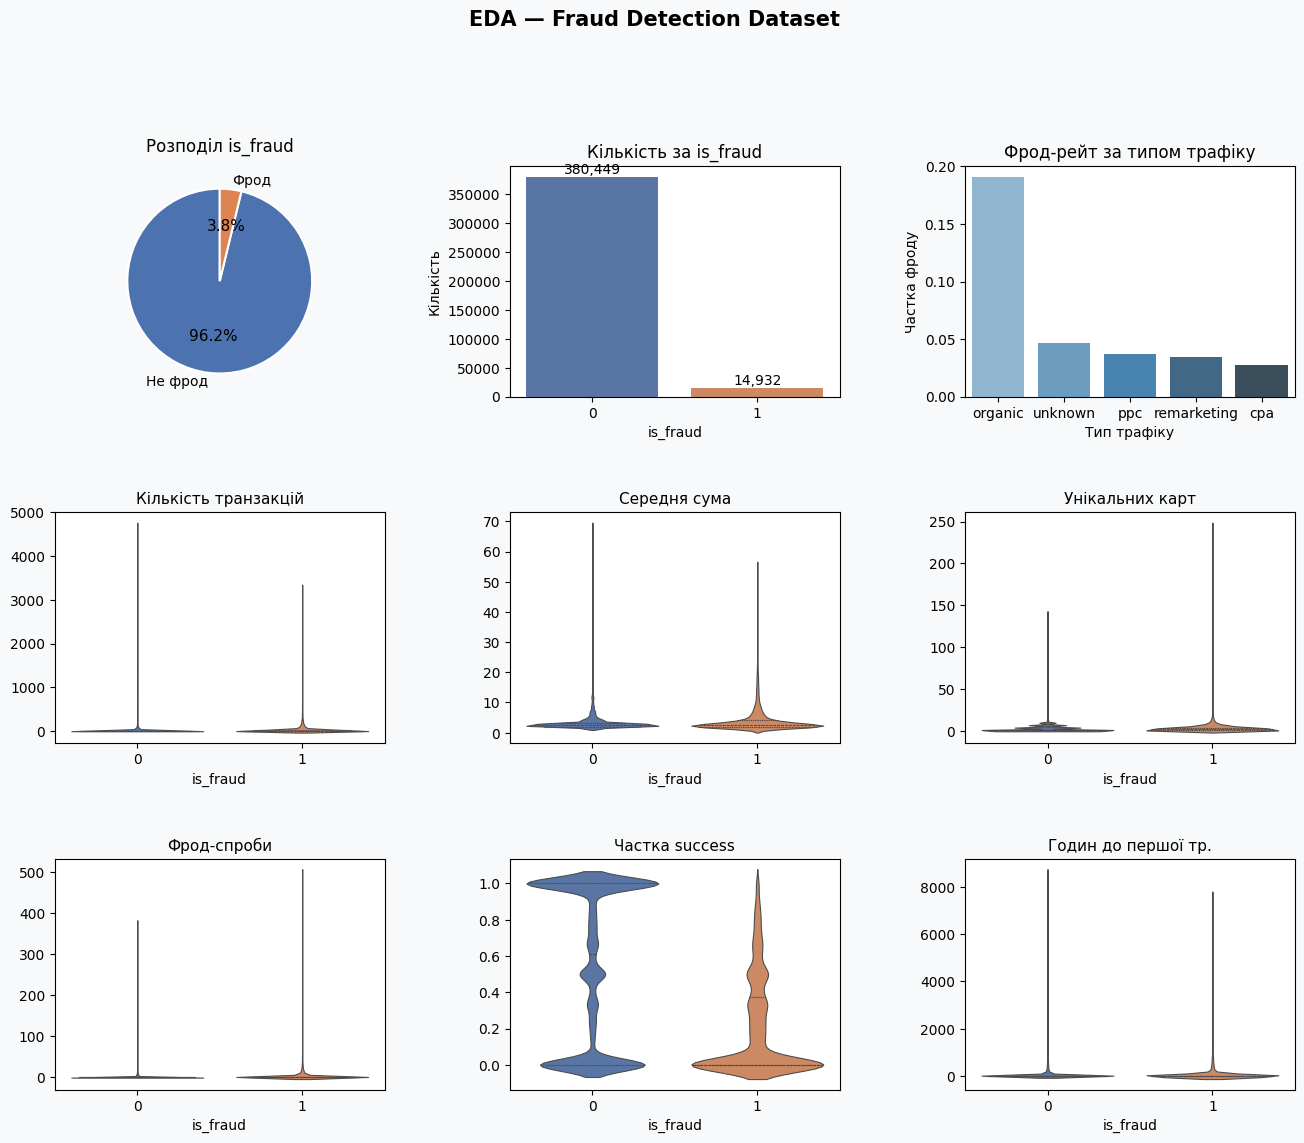


✓ Збережено: eda_distributions.png


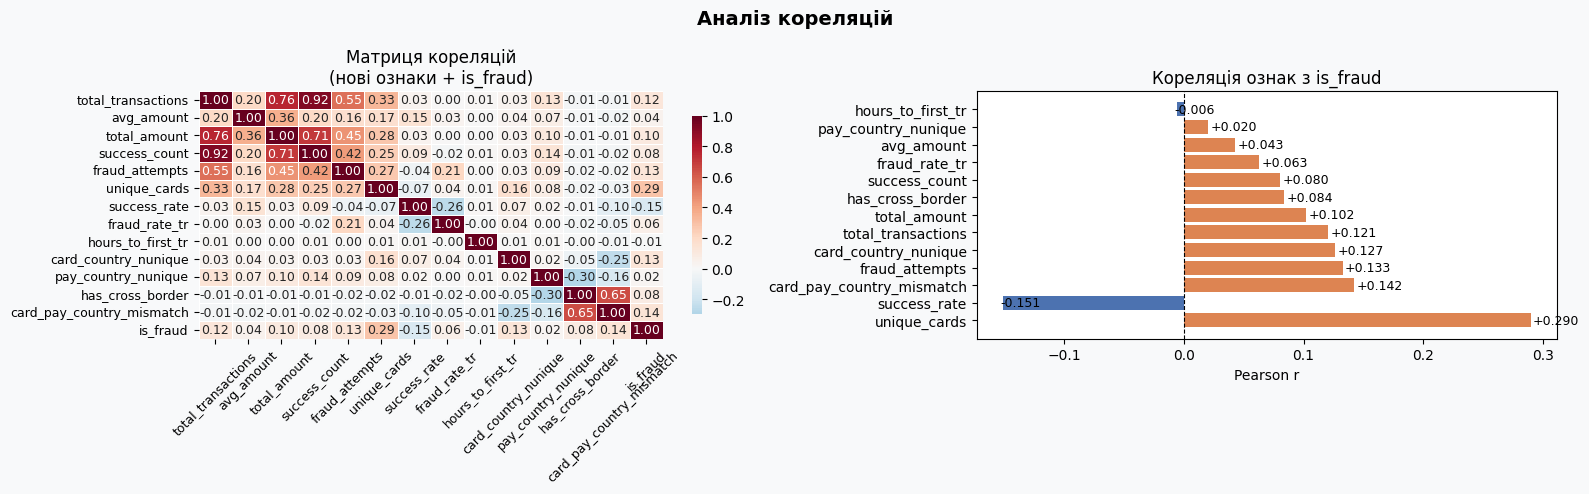

✓ Збережено: eda_correlations.png


In [30]:
# ─────────────────────────────────────────────
# 6. EDA — ВІЗУАЛІЗАЦІЯ
# ─────────────────────────────────────────────
# Нові числові ознаки для аналізу кореляцій
new_features = [
    "total_transactions", "avg_amount", "total_amount",
    "success_count", "fraud_attempts", "unique_cards",
    "success_rate", "fraud_rate_tr", "hours_to_first_tr",
    "card_country_nunique", "pay_country_nunique",
    "has_cross_border", "card_pay_country_mismatch",
]
 
# ── Рисунок 1: розподіл is_fraud + ключові ознаки ──────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("#F8F9FA")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)
 
# (a) Pie-chart is_fraud
ax0 = fig.add_subplot(gs[0, 0])
fraud_counts = df["is_fraud"].value_counts()
colors = ["#4C72B0", "#DD8452"]
wedges, texts, autotexts = ax0.pie(
    fraud_counts.values,
    labels=["Не фрод", "Фрод"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"},
)
for at in autotexts:
    at.set_fontsize(11)
ax0.set_title("Розподіл is_fraud", fontsize=12, pad=10)
 
# (b) Bar-chart is_fraud
ax1 = fig.add_subplot(gs[0, 1])
sns.countplot(data=df, x="is_fraud", palette=["#4C72B0", "#DD8452"], ax=ax1)
ax1.set_title("Кількість за is_fraud", fontsize=12)
ax1.set_xlabel("is_fraud"); ax1.set_ylabel("Кількість")
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}",
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha="center", va="bottom", fontsize=10)
 
# (c) is_fraud за traffic_type
ax2 = fig.add_subplot(gs[0, 2])
traffic_fraud = (
    df.groupby("traffic_type")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(data=traffic_fraud, x="traffic_type", y="is_fraud",
            palette="Blues_d", ax=ax2)
ax2.set_title("Фрод-рейт за типом трафіку", fontsize=12)
ax2.set_ylabel("Частка фроду"); ax2.set_xlabel("Тип трафіку")
 
# (d-i) Розподіл нових ознак (violin + swarm)
plot_features = [
    ("total_transactions", "Кількість транзакцій"),
    ("avg_amount",         "Середня сума"),
    ("unique_cards",       "Унікальних карт"),
    ("fraud_attempts",     "Фрод-спроби"),
    ("success_rate",       "Частка success"),
    ("hours_to_first_tr",  "Годин до першої тр."),
]
 
for idx, (col, title) in enumerate(plot_features):
    row, col_pos = divmod(idx, 3)
    ax = fig.add_subplot(gs[row + 1, col_pos])
    sns.violinplot(
        data=df, x="is_fraud", y=col,
        palette=["#4C72B0", "#DD8452"],
        inner="quartile", ax=ax, linewidth=0.8,
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("is_fraud"); ax.set_ylabel("")
 
fig.suptitle("EDA — Fraud Detection Dataset", fontsize=15, fontweight="bold", y=1.01)
plt.savefig("eda_distributions.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("\n✓ Збережено: eda_distributions.png")
 
# ── Рисунок 2: теплова карта кореляцій з is_fraud ──────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 5))
fig2.patch.set_facecolor("#F8F9FA")
 
# Повна кореляційна матриця
corr_matrix = df[new_features + ["is_fraud"]].corr()
 
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, linewidths=0.5, linecolor="white",
    ax=axes[0], cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9},
)
axes[0].set_title("Матриця кореляцій\n(нові ознаки + is_fraud)", fontsize=12)
axes[0].tick_params(axis="x", rotation=45, labelsize=9)
axes[0].tick_params(axis="y", rotation=0, labelsize=9)
 
# Топ-кореляції з is_fraud
corr_with_target = (
    corr_matrix["is_fraud"]
    .drop("is_fraud")
    .sort_values(key=abs, ascending=False)
)
colors_bar = ["#DD8452" if v > 0 else "#4C72B0" for v in corr_with_target.values]
axes[1].barh(corr_with_target.index, corr_with_target.values, color=colors_bar)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Кореляція ознак з is_fraud", fontsize=12)
axes[1].set_xlabel("Pearson r")
for i, (val, feat) in enumerate(zip(corr_with_target.values, corr_with_target.index)):
    axes[1].text(val + 0.002 * np.sign(val), i, f"{val:+.3f}",
                 va="center", fontsize=9)
 
fig2.suptitle("Аналіз кореляцій", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlations.png", bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()
print("✓ Збережено: eda_correlations.png")

In [21]:
# ─────────────────────────────────────────────
# 7. ПІДСУМКОВА СТАТИСТИКА
# ─────────────────────────────────────────────
print("\n" + "═" * 55)
print("ПІДСУМОК ДАТАСЕТУ")
print("═" * 55)
print(f"Рядків у фінальному df:        {df.shape[0]:,}")
print(f"Колонок:                       {df.shape[1]}")
print(f"Фрод-рейт (is_fraud):          {df['is_fraud'].mean():.2%}")
print(f"Без транзакцій (нових ознак=0):{(df['total_transactions'] == 0).sum():,}")
print(f"NaN у фінальному df:           {df.isnull().sum().sum()}")
print("\nПерші 5 рядків:")
print(df.head().to_string())


═══════════════════════════════════════════════════════
ПІДСУМОК ДАТАСЕТУ
═══════════════════════════════════════════════════════
Рядків у фінальному df:        395,381
Колонок:                       19
Фрод-рейт (is_fraud):          3.78%
Без транзакцій (нових ознак=0):0
NaN у фінальному df:           213059

Перші 5 рядків:
    id_user                    timestamp_reg                    email  gender reg_country traffic_type  is_fraud  total_transactions  avg_amount  total_amount  std_amount  success_count  fraud_attempts  unique_cards  unique_currencies  unique_pay_countries  success_rate  fraud_rate_tr  hours_to_first_tr
0  15383249 2025-07-16 19:01:23.868869+00:00  larsjohansson@gmail.com    male      Sweden          cpa         0                 536   13.718843       7353.30   12.522945            302               9            10                  1                     1        0.5634         0.0168               1.34
1   9458117 2025-05-04 19:30:02.902877+00:00        evamark@y

In [32]:
df.columns

Index(['id_user', 'timestamp_reg', 'email', 'gender', 'reg_country',
       'traffic_type', 'is_fraud', 'total_transactions', 'avg_amount',
       'total_amount', 'std_amount', 'success_count', 'fraud_attempts',
       'unique_cards', 'unique_currencies', 'unique_pay_countries',
       'success_rate', 'fraud_rate_tr', 'hours_to_first_tr',
       'card_country_top', 'payment_country_top', 'card_country_nunique',
       'pay_country_nunique', 'has_cross_border', 'card_pay_country_mismatch'],
      dtype='object')